# 段階反応モデル

**段階反応モデル（graded response model: GRM, [Samejima, 1969](https://link.springer.com/article/10.1007/BF03372160)）** は多値の順序尺度の反応を扱えるモデル。複数の二値IRTモデルを組み合わせて多値反応を表現する。

回答者$i$の項目$j$に対する回答$y_{ij} = k \ (k=1,2,\dots,K)$について、「$k$以上のカテゴリを選ぶ確率」を考えると、これはまだ「$k$未満 or $k$以上」の二値なので2PLなどで表せる。例えば以下のようになる。

$$
P(y_{ij} \geq k)
= \frac{1}{1+ \exp \big(-a_j ( \theta_i - b_{jk}) \big)}
$$

なお、困難度は項目$j$のカテゴリ$k$ごとに用意されるため$b_{jk}$に変更している。


このモデルを組み合わせると、「ちょうど$k$番目のカテゴリを選ぶ確率」は

$$
P(y_{ij} = k) = P(y_{ij} \geq k) - P(y_{ij} \geq k + 1)
$$

と表すことができる。ただし端のカテゴリは$P(y_{ij} \geq 1) = 1, P(y_{ij} \geq K + 1) = 0$とする。また確率100%の困難度は低くて当然なので$b_{j1} = -\infty$とする。

:::{admonition} 段階反応モデル

$$
P(y_{ij} = k) = \frac{1}{1+ \exp(-a_j (\theta_i - b_{jk}) )} - \frac{1}{1+ \exp(-a_j ( \theta_i - b_{jk+1}) )}
$$

:::

## 実装例（全項目のカテゴリ数が等しい場合）

PyMCパッケージを使ってベイズ推定する場合、各項目のカテゴリ数が同じ場合は順序ロジットモデルで簡単に実装できる

In [1]:
# データを生成
import numpy as np
import pandas as pd

def simulate_grm(N=1000, J=10, K=4, seed=42):
    rng = np.random.default_rng(seed)

    theta = rng.normal(0, 1, size=N)
    a = rng.lognormal(0, 0.3, size=J)
    b = np.sort(
        rng.normal(0, 1, size=(J, K-1)),
        axis=1
    )

    U = np.zeros((N, J), dtype=int)
    for j in range(J):
        for i in range(N):
            eta = a[j]*(theta[i] - b[j])
            P_ge = 1 / (1 + np.exp(-eta))

            P = np.empty(K)
            P[0] = 1 - P_ge[0]
            for k in range(1, K-1):
                P[k] = P_ge[k-1] - P_ge[k]
            P[K-1] = P_ge[K-2]

            U[i, j] = rng.choice(K, p=P)
    return U, theta, a, b

num_users = 1000
num_items = 20
U, true_theta, true_a, true_b = simulate_grm(N=num_users, J=num_items)
df = pd.DataFrame(U,
                  index=[f"user_{i+1}" for i in range(num_users)],
                  columns=[f"item_{j+1}" for j in range(num_items)])

df.head()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,item_18,item_19,item_20
user_1,0,3,3,0,3,3,3,3,3,1,3,1,3,0,2,1,3,0,0,1
user_2,0,0,0,0,0,0,0,0,0,3,0,1,0,3,0,0,0,0,1,0
user_3,3,0,3,3,3,0,3,0,3,3,2,1,3,0,3,3,0,1,1,0
user_4,0,1,1,1,0,3,1,1,3,3,3,1,3,3,2,3,3,3,3,1
user_5,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,2,0,2,0,0


In [2]:
# 縦持ちへ変換
user_categories = df.index
item_categories = df.columns

df_long = pd.melt(
    df.reset_index(),
    id_vars="index",
    var_name="item",
    value_name="response",
).rename(columns={"index": "user"})

df_long["user"] = pd.Categorical(df_long["user"], categories=user_categories, ordered=True)
df_long["item"] = pd.Categorical(df_long["item"], categories=item_categories, ordered=True)

df_long.head()

,user,item,response
0,user_1,item_1,0
1,user_2,item_1,0
2,user_3,item_1,3
3,user_4,item_1,0
4,user_5,item_1,0


### 閾値（cutpoints）の推定

[`pymc.OrderedLogistic`](https://www.pymc.io/projects/docs/en/latest/api/distributions/generated/pymc.OrderedLogistic.html) が $\text{logit}^{-1}(\eta - c_k)$ なので、IRTモデルの$\text{logit}^{-1}(a(\theta - b_k)) = \text{logit}^{-1}(a\theta - a b_k)$ に合わせると `cutpoints = a[:, None] * b` のようにするのが素直な実装。

```python
# --- GRM の閾値：各 item ごとに (K-1) 本 ---
# ordered transform が last axis に対して単調増加を強制する想定
b = pm.Normal(
    "b",
    mu=np.linspace(-1, 1, n_thresholds),
    sigma=2.0,
    dims=("item", "threshold"),
    initval=np.tile(np.linspace(-1, 1, n_thresholds), (num_items, 1)), # 初期値を指定
    transform=pm.distributions.transforms.ordered,
)

# GRM の cutpoints: a_j * b_{jk}
# OrderedLogistic は P(Y >= k) = sigma(eta - cutpoints_k) を計算するため、
# Samejima のパラメタリゼーション P(Y >= k) = sigma(a*(theta - b)) に合わせるには
# cutpoints = a * b とする必要がある（a > 0 なので順序は保たれる）
cutpoints = a[:, None] * b
```

しかし、これはaとbに依存が関係が生じてサンプリングが安定しにくいかもしれない。`cutpoints = pm.Normal()` にして `b = cutpoints / a[:, None]` としたほうが良いかも


In [75]:
import numpy as np
import pymc as pm

# indexと値の取得
user_idx = df_long["user"].cat.codes.to_numpy()
users = df_long["user"].cat.categories.to_numpy()
item_idx = df_long["item"].cat.codes.to_numpy()
items = df_long["item"].cat.categories.to_numpy()
responses = df_long["response"].to_numpy().astype("int64")  # 0..K-1

# カテゴリ数
K = int(responses.max() + 1)
n_thresholds = K - 1

coords = {
    "user": users,
    "item": items,
    "threshold": np.arange(n_thresholds),
    "obs_id": np.arange(len(df_long)),
}

with pm.Model(coords=coords) as model:
    responses_ = pm.Data("responses", responses, dims="obs_id")

    theta = pm.Normal("theta", 0.0, 1.0, dims="user")
    a = pm.LogNormal("a", 0.0, 0.5, dims="item")

    # --- 閾値：各 item ごとに (K-1) 本 ---
    b = pm.Normal(
        "b",
        mu=np.linspace(-1, 1, n_thresholds),
        sigma=2.0,
        dims=("item", "threshold"),
        initval=np.tile(np.linspace(-1, 1, n_thresholds), (num_items, 1)), # 初期値を指定
        transform=pm.distributions.transforms.ordered,
    )
    # OrderedLogistic は P(Y >= k) = inv_logit(eta - cutpoints_k) を計算するため、
    # GRM の P(Y >= k) = inv_logit(a*(theta - b_k)) に合わせてcutpoints_k = a * b_k
    cutpoints = pm.Deterministic("cutpoints", a[:, None] * b)

    # 線形予測子
    eta = pm.Deterministic("eta", a[item_idx] * theta[user_idx])

    # 観測：item ごとの cutpoints を観測ごとに参照
    pm.OrderedLogistic(
        "obs",
        eta=eta,
        cutpoints=cutpoints[item_idx],
        observed=responses_,
        dims="obs_id",
    )

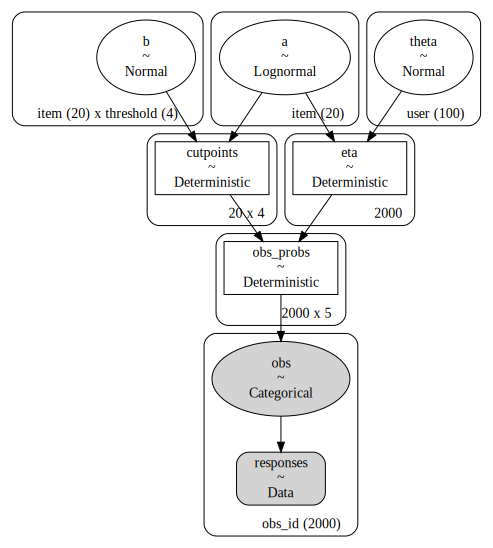

In [76]:
pm.model_to_graphviz(model)

#### 推定

In [5]:
%%time
with model:
    idata = pm.sample(random_seed=0, draws=1000, tune=2000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 114 seconds.


CPU times: user 16.5 s, sys: 5.18 s, total: 21.7 s
Wall time: 1min 59s


### EAP推定量


In [6]:
import arviz as az
az.summary(idata, var_names=["a", "b"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[item_1],0.94,0.09,0.77,1.12,0.0,0.0,2406.78,2928.07,1.00
a[item_2],0.75,0.07,0.62,0.89,0.0,0.0,1172.53,1324.90,1.00
a[item_3],0.90,0.08,0.75,1.05,0.0,0.0,1331.70,2025.87,1.00
a[item_4],1.13,0.10,0.96,1.31,0.0,0.0,2135.03,2944.66,1.00
a[item_5],0.88,0.08,0.74,1.05,0.0,0.0,1712.02,2359.38,1.01
...,...,...,...,...,...,...,...,...,...
"b[item_19, 1]",0.12,0.08,-0.04,0.26,0.0,0.0,2724.39,3421.61,1.00
"b[item_19, 2]",1.30,0.13,1.05,1.55,0.0,0.0,1597.53,2120.53,1.00
"b[item_20, 0]",-0.64,0.08,-0.78,-0.50,0.0,0.0,1336.95,2396.03,1.00
"b[item_20, 1]",1.38,0.11,1.18,1.58,0.0,0.0,2044.45,2471.56,1.00


In [7]:
post_mean = idata.posterior.mean(dim=["chain", "draw"])

# 項目パラメータのEAP推定量
params_EAP = pd.DataFrame({
    "item": coords["item"],
    "a": post_mean["a"],
})
params_EAP.head()

,item,a
0,item_1,0.944434
1,item_2,0.751282
2,item_3,0.898166
3,item_4,1.134108
4,item_5,0.884190


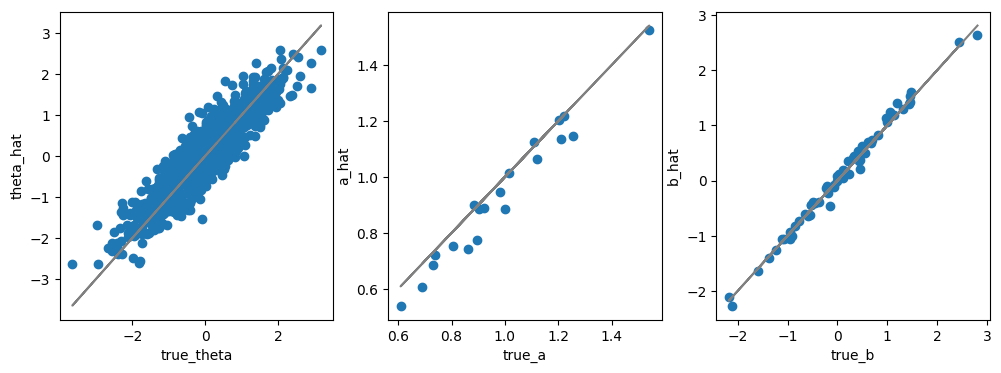

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=[12,4], ncols=3)

ax = axes[0]
ax.scatter(true_theta, post_mean["theta"])
ax.plot(true_theta, true_theta, color="gray")
_ = ax.set(xlabel="true_theta", ylabel="theta_hat")

ax = axes[1]
ax.scatter(true_a, post_mean["a"])
ax.plot(true_a, true_a, color="gray")
_ = ax.set(xlabel="true_a", ylabel="a_hat")

ax = axes[2]
ax.scatter(true_b.flatten(), post_mean["b"].to_numpy().flatten())
ax.plot(true_b, true_b, color="gray")
_ = ax.set(xlabel="true_b", ylabel="b_hat")

## 実装例（各項目のカテゴリ数が異なる場合）

OrderedLogisticを複数個重ねるように実装する方法がある

In [14]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items total

# K per item
K_per_item = np.array([3] * 7 + [4] * 7 + [5] * 6)

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
# b_true[j]: sorted array of K_j-1 thresholds
b_true = [np.sort(rng.normal(0, 1, K_per_item[j] - 1)) for j in range(J)]

# Generate responses
Y = np.zeros((N, J), dtype=int)
for j in range(J):
    K_j = K_per_item[j]
    # P*(Y >= k) for k=1,...,K_j-1 — shape (N, K_j-1)
    eta = a_true[j] * (theta_true[:, None] - b_true[j][None, :])
    cum_p = 1 / (1 + np.exp(-eta))
    probs = np.concatenate([
        1 - cum_p[:, :1],
        cum_p[:, :-1] - cum_p[:, 1:],
        cum_p[:, -1:],
    ], axis=1)  # (N, K_j)
    u = rng.uniform(size=(N, 1))
    Y[:, j] = (u > np.cumsum(probs, axis=1)).sum(axis=1)

print(f"Response matrix shape: {Y.shape}")
for k in np.unique(K_per_item):
    items_k = np.where(K_per_item == k)[0]
    counts = np.bincount(Y[:, items_k].ravel(), minlength=k)
    print(f"K={k}: {len(items_k)} items, category counts = {counts}")

Response matrix shape: (100, 20)
K=3: 7 items, category counts = [275 154 271]
K=4: 7 items, category counts = [256  85 113 246]
K=5: 6 items, category counts = [193  38  92 124 153]


In [15]:
df = pd.DataFrame(Y,
                  index=[f"user_{i+1}" for i in range(Y.shape[0])],
                  columns=[f"item_{j+1}" for j in range(Y.shape[1])])

df.tail()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,item_18,item_19,item_20
user_96,0,0,0,0,0,0,0,0,0,0,0,2,3,3,0,0,0,4,0,3
user_97,2,0,0,1,0,2,0,1,0,0,2,0,0,3,2,0,0,1,0,0
user_98,2,0,0,0,0,2,0,0,0,0,1,0,0,3,0,1,2,0,0,4
user_99,0,1,0,1,0,1,1,3,0,3,2,2,2,3,3,0,2,4,3,4
user_100,0,1,0,1,0,2,0,3,0,0,0,0,0,0,2,3,2,0,0,4


In [16]:
# 縦持ちへ変換
user_categories = df.index
item_categories = df.columns

df_long = pd.melt(
    df.reset_index(),
    id_vars="index",
    var_name="item",
    value_name="response",
).rename(columns={"index": "user"})

df_long["user"] = pd.Categorical(df_long["user"], categories=user_categories, ordered=True)
df_long["item"] = pd.Categorical(df_long["item"], categories=item_categories, ordered=True)

df_long.head()

,user,item,response
0,user_1,item_1,2
1,user_2,item_1,0
2,user_3,item_1,2
3,user_4,item_1,2
4,user_5,item_1,0


In [17]:
import numpy as np
import pymc as pm

# indexと値の取得
user_idx = df_long["user"].cat.codes.to_numpy()
users = df_long["user"].cat.categories.to_numpy()
item_idx = df_long["item"].cat.codes.to_numpy()
items = df_long["item"].cat.categories.to_numpy()
responses = df_long["response"].to_numpy().astype("int64")  # 0..K-1

# カテゴリ数
K = int(responses.max() + 1)
n_thresholds = K - 1

coords = {
    "user": users,
    "item": items,
    "threshold": np.arange(n_thresholds),
    "obs_id": np.arange(len(df_long)),
}

with pm.Model(coords=coords) as model:
    responses_ = pm.Data("responses", responses, dims="obs_id")

    theta = pm.Normal("theta", 0.0, 1.0, dims="user")
    a = pm.LogNormal("a", 0.0, 0.5, dims="item")

    # --- GRM の閾値：各 item ごとに (K-1) 本 ---
    # ordered transform が last axis に対して単調増加を強制する想定
    b = pm.Normal(
        "b",
        mu=np.linspace(-1, 1, n_thresholds),   # 初期の目安
        sigma=2.0,
        dims=("item", "threshold"),
        transform=pm.distributions.transforms.ordered,
    )
    # 線形予測子
    eta = a[item_idx] * theta[user_idx]

    # GRM の cutpoints: a_j * b_{jk}
    # OrderedLogistic は P(Y >= k) = sigma(eta - cutpoints_k) を計算するため、
    # Samejima のパラメタリゼーション P(Y >= k) = sigma(a*(theta - b)) に合わせるには
    # cutpoints = a * b とする必要がある（a > 0 なので順序は保たれる）
    cutpoints = a[:, None] * b

    # 観測：item ごとの cutpoints を観測ごとに参照
    pm.OrderedLogistic(
        "obs",
        eta=eta,
        cutpoints=cutpoints[item_idx],
        observed=responses_,
        dims="obs_id",
    )

### モデル

[荘島宏二郎 & 豊田秀樹 (2004)](https://www.jstage.jst.go.jp/article/jjep1953/52/1/52_61/_article/-char/ja/) を参考に、複数のモデルの尤度を掛けるようにして混合形式のモデルを構築する。

ある項目$j$のカテゴリ数が$k$個だとし、それをGRMでモデリングした項目特性曲線を $P^{GRM(k)}_j(\theta)$ とすると、今回のデータはカテゴリ数が$k=3$の項目が7個、$k=4$の項目が7個、$k=5$の項目が6個なので

$$
L(\theta) = \prod_{i=1}^N \left\{
\prod_{j=1}^7 P^{GRM(3)}_j(\theta_i) 
\times \prod_{j=1}^7 P^{GRM(4)}_j(\theta_i) 
\times \prod_{j=1}^6 P^{GRM(5)}_j(\theta_i) 
\right\}
$$

となる。同じカテゴリ数の項目ごとにグルーピングして実装すれば


```python
with pm.Model() as model:
    for k in [3, 4, 5]:
        subset = data[K_per_item == k] # 対応する項目を取り出す
        pm.OrderedLogistic(...) # GRMを構築
        ...
```

のように実装できる



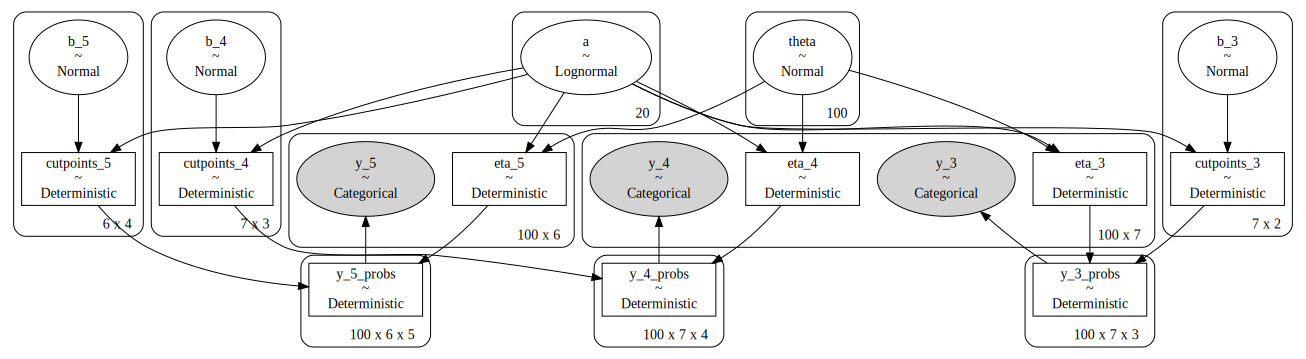

In [19]:
K_per_item = df.max() + 1
unique_K = np.sort(np.unique(K_per_item))

with pm.Model() as model:
    # theta, aはkによらず共通
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, shape=N)
    a = pm.LogNormal("a", mu=0.0, sigma=0.5, shape=J)

    # カテゴリ数Kが同じ項目ごとにまとめてGRMを構築
    for k in unique_K:
        item_idx = np.where(K_per_item == k)[0]
        J_k = len(item_idx)
        Y_k = Y[:, item_idx]  # (N, J_k)
        b_k = pm.Normal(
            f"b_{k}",
            mu=0.0,
            sigma=1.5,
            shape=(J_k, k - 1),
            transform=pm.distributions.transforms.ordered,
            initval=np.tile(np.linspace(-1.0, 1.0, k - 1), (J_k, 1)),
        )

        eta_k = pm.Deterministic(f"eta_{k}",theta[:, None] * a[item_idx][None, :])   # (N, J_k)
        cutpoints_k = pm.Deterministic(f"cutpoints_{k}", a[item_idx][:, None] * b_k)  # (J_k, K-1)

        pm.OrderedLogistic(
            f"y_{k}",
            eta=eta_k,
            cutpoints=cutpoints_k,
            observed=Y_k,
        )

pm.model_to_graphviz(model)

In [20]:
with model:
    idata = pm.sample(
        draws=3000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        nuts_sampler="numpyro",
    )


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

### EAP推定値

In [43]:
item_params = pd.DataFrame({"item": df.columns})
item_params["a"] = idata.posterior["a"].mean(dim=["chain", "draw"]).values  # (J,)

for k in K_per_item.unique():
    b_col = f"b_{k}"
    B_k = idata.posterior[b_col].mean(dim=["chain", "draw"]).values
    J_k = B_k.shape[1]
    B_df = pd.DataFrame(B_k, columns=[f"b{i+1}" for i in range(J_k)])
    for col in B_df.columns:
        item_params.loc[np.array(k == K_per_item), col] = B_df[col].values

# mirtパッケージのような表
item_params

,item,a,b1,b2,b3,b4
0,item_1,0.489036,-0.561038,0.347300,NaN,NaN
1,item_2,1.996779,0.126741,1.518604,NaN,NaN
2,item_3,0.644764,0.497665,0.870190,NaN,NaN
3,item_4,1.092062,-1.700215,2.220444,NaN,NaN
4,item_5,0.851446,-1.085440,-0.830939,NaN,NaN
5,item_6,0.634875,-1.676081,-0.222854,NaN,NaN
6,item_7,0.666209,-0.536491,0.720370,NaN,NaN
7,item_8,0.932530,-1.359590,-0.638903,0.599335,NaN
8,item_9,1.832579,0.628938,1.822901,2.857112,NaN
9,item_10,0.436971,-1.925663,-0.699537,0.517263,NaN


In [22]:
theta_mean = idata.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
thetas = pd.DataFrame({"person": np.arange(N), "theta": theta_mean})

### 真値と比較

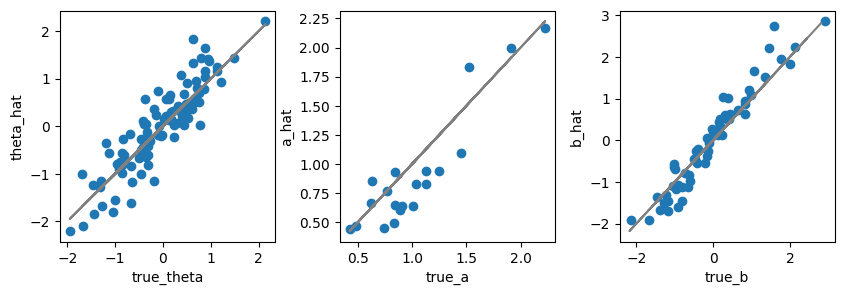

In [74]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=[10,3], ncols=3)

ax = axes[0]
ax.scatter(theta_true, theta_mean)
ax.plot(theta_true, theta_true, color="gray")
_ = ax.set(xlabel="true_theta", ylabel="theta_hat")

ax = axes[1]
ax.scatter(a_true, item_params["a"])
ax.plot(a_true, a_true, color="gray")
_ = ax.set(xlabel="true_a", ylabel="a_hat")

ax = axes[2]
b_hat_flatten = item_params.filter(regex="b\d").to_numpy().flatten()
ax.scatter(np.concatenate(b_true), b_hat_flatten[~np.isnan(b_hat_flatten)])
ax.plot(true_b, true_b, color="gray")
_ = ax.set(xlabel="true_b", ylabel="b_hat")

fig.subplots_adjust(wspace=0.3)

## 分析手順

チュートリアル論文 [Zein, R. A., & Akhtar, H. (2025). Getting started with the graded response model: an introduction and tutorial in R](https://onlinelibrary.wiley.com/doi/10.1002/ijop.13265) によると



## 参考文献

- [Samejima, F. (1969). Estimation of latent ability using a response pattern of graded scores. Psychometrika, 34(S1), 1-97.](https://link.springer.com/article/10.1007/BF03372160)
- Lipovetsky, S. (2021). Handbook of Item Response Theory, Volume 1, Models. Technometrics, 63(3), 428-431.